ref:
https://github.com/abhisheksuran/Reinforcement_Learning/blob/master/Td3.py  
gym:https://www.gymlibrary.dev/environments/box2d/lunar_lander/

In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [ ]:
from variable_print import p,ps,pst

In [ ]:
%%time
%%capture
!pip install swig
!pip install gymnasium[box2d] #
import gymnasium as gym  ###

CPU times: user 3.58 s, sys: 624 ms, total: 4.21 s
Wall time: 8.83 s


Wall time: 53.7 s



In [ ]:
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchsummary as summary
import time
import random

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

# LunarLander_Continuous Environment

In [ ]:
problem = "LunarLanderContinuous-v3"  ###
env = gym.make(problem, render_mode="rgb_array")

num_states = env.observation_space.shape[0]      # 8
ps(env.observation_space,'Shape of State Space') #(8,)
p(env.observation_space,'env.observation_space')
print(f'state_low::{env.observation_space.low}')
print(f'state_high::{env.observation_space.high}\n')

num_actions = env.action_space.shape[0] # 2
ps(env.action_space,'Shape of Action Space') #(2,)
p(env.action_space,'env.action_space')
print(f'action_low::{env.action_space.low}')
print(f'action_high::{env.action_space.high}\n')

max_action = float(env.action_space.high[0])
print(f"Max Action: {max_action}\n")

state = env.reset()
p(state,'state') #(8,)

<<Shape of State Space>> Shape(8,)
<<env.observation_space>>:
Shape:(8,)
Type: <class 'gymnasium.spaces.box.Box'>
Values: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
state_low::[ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
state_high::[ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

<<Shape of Action Space>> Shape(2,)
<<env.action_space>>:
Shape:(2,)
Type: <class 'gymnasium.spaces.box.Box'>
Values: Box(-1.0, 1.0, (2,), float32)
action_low::[-1. -1.]
action_high::[1. 1.]

Max Action: 1.0

<<state>>:
Type: <class 'tuple'>
Values: (array([-0.00386915,  1.4107616 , -0.39192325, -0.00705048,  0.00449021,
        0.08877642,  0.        ,  0.        ], dtype=float32), {})


\[env.observation_space]:Shape:(8,)    
Type: <class 'gym.spaces.box.Box'>   
Values: Box(   
 [-1.5  -1.5   -5.   -5.  -3.1415927  -5.   -0.  -0. ],  
 [1.5   1.5     5.    5.   3.1415927   5.    1.   1. ], (8,), float32 )     
state_low:: [-1.5  -1.5    -5.   -5.   -3.1415927 -5.   -0.   -0. ]  
state_high:: [1.5    1.5     5.    5.    3.1415927 5.     1.   1. ]    

\[env.action_space]: Shape:(2,)    
Type: <class 'gym.spaces.box.Box'>  
Values: Box(-1.0, 1.0, (2,), float32)  
action_low::[-1. -1.]  
action_high::[1. 1.]    

\[state]:  Shape:(8,)    
Type: <class 'numpy.ndarray'>  
Values: [-0.0064477 1.4049095 -0.6530905 -0.2671648  0.00747799 0.14793481 0.   0. ]  

# Replay Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, max_size, state_dim, action_dim):
        self.max_size = max_size
        self.ptr = 0
        self.size = 0

        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.next_state = np.zeros((max_size, state_dim))
        self.reward = np.zeros((max_size, 1))
        self.not_done = np.zeros((max_size, 1))

    def add(self, state, action, next_state, reward, done):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.next_state[self.ptr] = next_state
        self.reward[self.ptr] = reward
        self.not_done[self.ptr] = 1. - done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        ind = np.random.randint(0, self.size, size=batch_size)

        return (
            torch.FloatTensor(self.state[ind]),
            torch.FloatTensor(self.action[ind]),
            torch.FloatTensor(self.next_state[ind]),
            torch.FloatTensor(self.reward[ind]),
            torch.FloatTensor(self.not_done[ind])
        )

# TD3

## Actor-Network, Critic-Network

In [ ]:
hidden_units = 256

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action=2):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, action_dim)
        self.max_action = max_action

    def forward(self, state):
        a = F.relu(self.fc1(state))
        a = F.relu(self.fc2(a))
        return self.max_action * torch.tanh(self.fc3(a))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        # Q1 architecture
        self.fc1 = nn.Linear(state_dim + action_dim, hidden_units)
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        self.fc3 = nn.Linear(hidden_units, 1)
        # Q2 architecture
        self.fc4 = nn.Linear(state_dim + action_dim, hidden_units)
        self.fc5 = nn.Linear(hidden_units, hidden_units)
        self.fc6 = nn.Linear(hidden_units, 1)

    def forward(self, state, action):
        sa = torch.cat([state, action], 1)
        q1 = F.relu(self.fc1(sa))
        q1 = F.relu(self.fc2(q1))
        q1 = self.fc3(q1)

        q2 = F.relu(self.fc4(sa))
        q2 = F.relu(self.fc5(q2))
        q2 = self.fc6(q2)
        return q1, q2

    def Q1(self, state, action):
        sa = torch.cat([state, action], 1)
        q1 = F.relu(self.fc1(sa))
        q1 = F.relu(self.fc2(q1))
        q1 = self.fc3(q1)
        return q1

## TD3 Agent

In [ ]:
class TD3Agent:
    def __init__(self, state_dim, action_dim, max_action):
        self.actor = Actor(state_dim, action_dim, max_action)
        self.actor_target = Actor(state_dim, action_dim, max_action)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)

        self.critic = Critic(state_dim, action_dim)
        self.critic_target = Critic(state_dim, action_dim)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.max_action = max_action
        self.total_it = 0

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1))
        return self.actor(state).cpu().data.numpy().flatten()

    def train(self, replay_buffer, batch_size=256):
        self.total_it += 1
        state, action, next_state, reward, not_done = replay_buffer.sample(batch_size)

        with torch.no_grad():
            # Target Policy Smoothing
            noise = (torch.randn_like(action) * policy_noise).clamp(-noise_clip, noise_clip)
            next_action = (self.actor_target(next_state) + noise).clamp(-self.max_action, self.max_action)

            # Clipped Double-Q Learning (Target Q 계산)
            target_Q1, target_Q2 = self.critic_target(next_state, next_action)
            target_Q = torch.min(target_Q1, target_Q2)
            target_Q = reward + not_done * gamma * target_Q

        # Critic 업데이트
        current_Q1, current_Q2 = self.critic(state, action)
        critic_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Delayed Policy Update (Actor 업데이트)
        if self.total_it % policy_freq == 0:
            actor_loss = -self.critic.Q1(state, self.actor(state)).mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            # Target 네트워크 Soft Update
            for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

    def save_model(self, path):
        torch.save(self.actor.state_dict(), path + "_actor.pth")
        torch.save(self.critic.state_dict(), path + "_critic.pth")

    def load_model(self, path):
        self.actor.load_state_dict(torch.load(path + "_actor.pth"))
        self.critic.load_state_dict(torch.load(path + "_critic.pth"))
        self.actor.eval()
        self.critic.eval()


## Training

In [ ]:
%%time
gamma = 0.99
tau = 0.005
policy_noise = 0.2
noise_clip = 0.5
policy_freq = 2 # Actor 업데이트 주기 (Critic 업데이트 2번 당 1번)
critic_lr = 1e-1
actor_lr = 1e-4
buffer_capacity = 500000 # 1000000
batch_size = 256
total_timesteps = 30000 #100000
start_timesteps = 10000 #25000 # 학습 시작 전 랜덤 행동
expl_noise = 0.1

agent = TD3Agent(num_states, num_actions, max_action)
replay_buffer = ReplayBuffer(buffer_capacity, num_states, num_actions)
ep_reward_list = []
avg_reward_list = []
model_path = "td3_lunarlander_best.pth"

print("학습을 시작합니다...")
state, info = env.reset()
done = False
episode_reward = 0
episode_timesteps = 0
episode_num = 0

for t in range(int(total_timesteps)):
    episode_timesteps += 1

    if t < start_timesteps:
        action = env.action_space.sample()
    else:
        action = (
            agent.select_action(np.array(state))
            + np.random.normal(0, max_action * expl_noise, size=num_actions)
        ).clip(-max_action, max_action)

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    replay_buffer.add(state, action, next_state, reward, float(done))
    state = next_state
    episode_reward += reward

    if t >= start_timesteps:
        agent.train(replay_buffer, batch_size)
#    if episode_timesteps >600 : done = True ## 강제 종료
    if done:
        print(f"Total T: {t+1} Episode Num: {episode_num+1} Episode T: {episode_timesteps} Reward: {episode_reward:.3f}")
        ep_reward_list.append(episode_reward)

        state, info = env.reset()
        done = False
        episode_reward = 0
        episode_timesteps = 0
        episode_num += 1

agent.save_model(model_path)
#env.close()
print("학습 종료!")
# Wall time: 57.5 s @ 10,000

학습을 시작합니다...
Total T: 98 Episode Num: 1 Episode T: 98 Reward: -326.211
Total T: 181 Episode Num: 2 Episode T: 83 Reward: -64.262
Total T: 260 Episode Num: 3 Episode T: 79 Reward: -126.117
Total T: 339 Episode Num: 4 Episode T: 79 Reward: -11.013
Total T: 488 Episode Num: 5 Episode T: 149 Reward: -113.929
Total T: 591 Episode Num: 6 Episode T: 103 Reward: -406.926
Total T: 715 Episode Num: 7 Episode T: 124 Reward: -150.433
Total T: 867 Episode Num: 8 Episode T: 152 Reward: -237.009
Total T: 974 Episode Num: 9 Episode T: 107 Reward: -134.273
Total T: 1114 Episode Num: 10 Episode T: 140 Reward: -126.962
Total T: 1183 Episode Num: 11 Episode T: 69 Reward: -71.741
Total T: 1300 Episode Num: 12 Episode T: 117 Reward: -367.530
Total T: 1380 Episode Num: 13 Episode T: 80 Reward: -224.805
Total T: 1476 Episode Num: 14 Episode T: 96 Reward: -230.371
Total T: 1550 Episode Num: 15 Episode T: 74 Reward: -118.762
Total T: 1636 Episode Num: 16 Episode T: 86 Reward: -131.905
Total T: 1723 Episode Num:

## Evaluation

In [ ]:
condition = f'buffer_capacity:{buffer_capacity/1000}k, hidden_units:{hidden_units}, '+\
            f'batch_size:{batch_size}, tau:{tau},\n policy_freq:{policy_freq},'+\
            f'total_timesteps:{total_timesteps/1000}k, start_timesteps:{start_timesteps/1000}k\n '+\
            f'critic_lr:{critic_lr}, actor_lr:{actor_lr}, expl_noise:{expl_noise}'

plt.figure(figsize=(5, 3))
plt.plot(np.array(ep_reward_list))
plt.title(f"TD3 scores for LunarLander\n {condition}")
plt.xlabel("Episode")
plt.ylabel("Avg. Episodic Reward")
plt.grid()
plt.show()

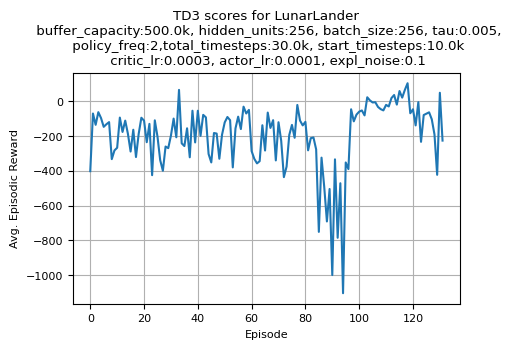

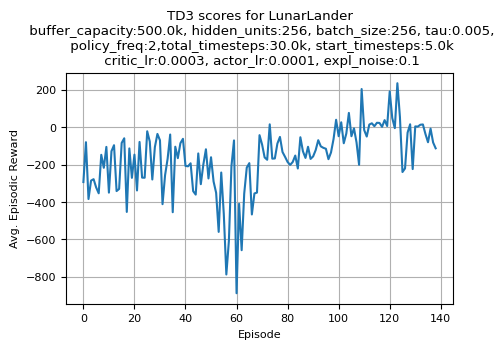

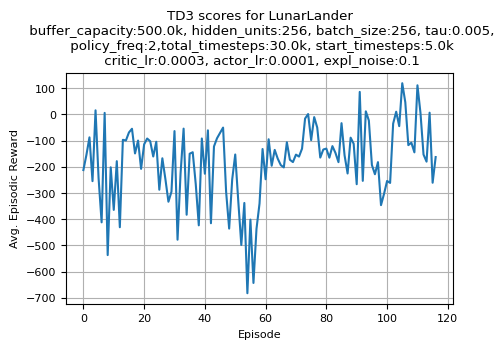

## Test

In [ ]:
total_reward = 0
state, _ = env.reset()
done = False
cnt = 0
while not done:
#    action = agent.actor_main(state.reshape(1,8))
    action = agent.select_action(np.array(state))
    next_state, reward, done, _, _ = env.step(action)
    state = next_state
    total_reward += reward
    cnt += 1
    if done:
       print(f'cnt:{cnt},reward:{total_reward}')

cnt:65,reward:-156.09270731828784


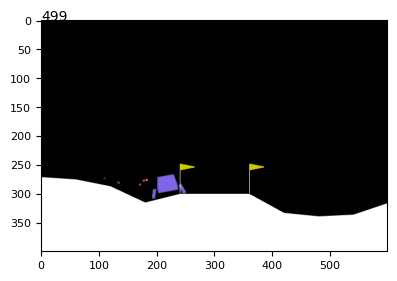

60.5305387461867


In [ ]:
from IPython.display import clear_output
import numpy as np

observation,_ = env.reset()
action_l = []
rewards = 0
for i in range(500): # while True:
    plt.figure(figsize=(5,3))
    img_data = env.render()
    plt.imshow(np.array(img_data, dtype=np.uint8))
    plt.text(0,0,str(i),fontsize=10)
    action = agent.select_action(np.array(observation))
    observation, reward, done , info, _ = env.step(action)
    clear_output(wait=True)
    rewards += reward
    if done: break;
    else: plt.show() # show the plot only if the episode is not done
plt.show()
print(rewards)
env.close()

In [ ]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

CPU times: user 1.89 s, sys: 364 ms, total: 2.25 s
Wall time: 44 s


In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
problem = "LunarLanderContinuous-v3"  ###
env = gym.make(problem,render_mode="rgb_array")

In [ ]:
def run_cartpole(env,step=500):
    observation, _ = env.reset()
    for i in range(step):
        render_as_image(env,step=i)
        if observation[2] < 0 : # pole angle
          action = 0            # push to the left
        else: action = 1        #        ``   right
        observation, reward, done , info, _ = env.step(action)
        if done: break;
    env.close()

In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

/content/gdrive/MyDrive/Colab Notebooks/video/TD3-LundarLander-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

/content/gdrive/MyDrive/Colab Notebooks/video/TD3-LundarLander-episode-0.mp4


# 실습과제 : Hyper Parameter tuning    
#### n_episode = 100 으로 고정하고,  
#### learning_rate = 0.01, 0.005, 0.0001, ?   
#### tau = 0.009, 0.05, 0.03, 0.01, 1, ?   
#### batch_size = 32, 64, 128, 256, ?  
#### n_RBuffer = 5000, 10000, 20000, ?  
#### Warmup = 100, 200, ?  

# 실습과제 2 : Ablation study     
## TD3 - DP - TPS - CDQ = DDPQ style  
#### Delayed policy update  
#### * self.actor_update_steps = 2 수정      
#### Target policy smoothing  
#### * target_actions += tf.clip_by_value( target_noise, -0.5, 0.5 )  
#### Clipped Double Q-learning  
#### * Clitic Net. 1, 2 --> Single Clitic Net.  

In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')